# Step 11 — Thesis figure and graph statistics

Two small, self-contained deliverables for the thesis write-up:

1. **Order-product graph statistics** (Section 3.3.1): node / edge counts, mean degrees and the degree spread, computed from `data/order_products__prior.csv` restricted to the scope the thesis reports (the 3,214,874 prior orders of `data/orders.csv`; the 49,677 products that appear in at least one of them). Written to `outputs/figures/graph_stats.json`.
2. **Kneedle figure** (Section 3.4): the similarity curve `sigma_a` of one real evaluation anchor, with the Kneedle knee at S = 1.0, the constant baseline theta = 0.70, and the cut that percentage drop-off at delta = 0.10 makes for the same anchor. Written to `outputs/figures/kneedle_curve.pdf` and `.png`.

**Read-only.** This notebook only *reads* existing data, embeddings and outputs, and writes new files into `outputs/figures/` (`graph_stats.json`, `kneedle_curve.pdf`, `kneedle_curve.png`). It regenerates no walks, filters or models. The thresholds in Part 2 are computed with the pipeline's own functions (`filter_lib_fullscale.kneedle_theta` and `filter_lib_fullscale.pct_dropoff_theta`), not a reimplementation.

## 1. Imports, paths, and style

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt   # matplotlib only, no seaborn

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
FULL_SCALE_DIR = OUT_DIR / "full_scale"
FILTERS_DIR = FULL_SCALE_DIR / "filters"
STEP1_DIR = OUT_DIR / "step1"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The pipeline's own thresholding code (project root), imported rather than re-implemented.
sys.path.insert(0, str(ROOT))
import filter_lib_fullscale as fl

# ---- Thesis figure style (identical to notebook 08: 9pt ticks, 10pt labels, embedded fonts) ----
mpl.rcParams.update({
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.labelsize": 10, "legend.fontsize": 8, "font.size": 9,
    "axes.linewidth": 0.8, "lines.linewidth": 1.3, "lines.markersize": 4,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # TrueType, not Type-3 -> editable/selectable text
    "savefig.bbox": "tight", "figure.dpi": 110,
})
FIG_WIDTH = 6.5   # inches — thesis text width

print("ROOT     :", ROOT)
print("figures  :", FIG_DIR)
print("pipeline :", fl.__file__)

ROOT     : /Users/linnhtet/Developer/bachelor-thesis
figures  : /Users/linnhtet/Developer/bachelor-thesis/outputs/figures
pipeline : /Users/linnhtet/Developer/bachelor-thesis/filter_lib_fullscale.py


# Part 1 — Order-product graph statistics

## 2. Load the prior order-products table and apply the thesis scope

The graph is bipartite: **product nodes** on one side, **order nodes** on the other, one edge per (order, product) incidence. Scope, exactly as the thesis reports it:

* orders = the `eval_set == "prior"` orders of `data/orders.csv` (3,214,874);
* products = those that appear in at least one of them (49,677 of the 49,688-product catalogue).

The scope restriction keeps only rows of `order_products__prior.csv` whose `order_id` is one of those prior orders. Every row of the file should already satisfy this; the cell counts and prints how many rows (if any) the restriction drops, rather than assuming zero.

In [2]:
orders = pd.read_csv(DATA_DIR / "orders.csv", usecols=["order_id", "eval_set"])
prior_order_ids = orders.loc[orders["eval_set"] == "prior", "order_id"]
PRIOR_ORDER_SET = set(prior_order_ids.to_numpy().tolist())

prior_all = pd.read_csv(
    DATA_DIR / "order_products__prior.csv",
    usecols=["order_id", "product_id"],
    dtype={"order_id": "int32", "product_id": "int32"},
)

in_scope = prior_all["order_id"].isin(PRIOR_ORDER_SET)
prior = prior_all.loc[in_scope]

n_rows_raw = len(prior_all)
n_rows_scoped = len(prior)
n_rows_dropped = n_rows_raw - n_rows_scoped
n_dup_pairs = int(prior.duplicated(subset=["order_id", "product_id"]).sum())

print(f"prior orders in orders.csv (eval_set == 'prior')   : {len(PRIOR_ORDER_SET):,}")
print(f"rows in order_products__prior.csv (raw)            : {n_rows_raw:,}")
print(f"rows kept by the scope restriction                 : {n_rows_scoped:,}")
print(f"rows DROPPED by the scope restriction              : {n_rows_dropped:,}")
print(f"duplicate (order, product) pairs among kept rows   : {n_dup_pairs:,}")

prior orders in orders.csv (eval_set == 'prior')   : 3,214,874
rows in order_products__prior.csv (raw)            : 32,434,489
rows kept by the scope restriction                 : 32,434,489
rows DROPPED by the scope restriction              : 0
duplicate (order, product) pairs among kept rows   : 0


## 3. Graph statistics

Degrees are computed per node from the scoped table. A product's degree is the number of distinct orders containing it; an order's degree is the number of distinct products in it. Density is the bipartite density `E / (P * O)`: the share of all possible (product, order) pairs that are actual edges.

In [3]:
edges = prior.drop_duplicates(subset=["order_id", "product_id"])   # no-op if there are no duplicates

deg_product = edges.groupby("product_id")["order_id"].size()   # orders per product
deg_order = edges.groupby("order_id")["product_id"].size()     # products per order

n_products = int(deg_product.shape[0])
n_orders = int(deg_order.shape[0])
n_edges = int(len(edges))

products_catalog = pd.read_csv(DATA_DIR / "products.csv", usecols=["product_id", "product_name"])
n_catalog = len(products_catalog)
top_pid = int(deg_product.idxmax())
top_name = products_catalog.loc[products_catalog["product_id"] == top_pid, "product_name"].iloc[0]

stats = {
    "scope": {
        "orders": "eval_set == 'prior' in data/orders.csv",
        "products": "products appearing in at least one prior order",
        "source_table": "data/order_products__prior.csv",
        "rows_raw": n_rows_raw,
        "rows_in_scope": n_rows_scoped,
        "rows_dropped_by_scope": n_rows_dropped,
        "duplicate_order_product_pairs": n_dup_pairs,
        "catalog_products": n_catalog,
        "catalog_products_never_in_a_prior_order": n_catalog - n_products,
    },
    "nodes": {
        "product_nodes": n_products,
        "order_nodes": n_orders,
        "total_nodes": n_products + n_orders,
    },
    "edges": {"total_edges": n_edges},
    "density": {"bipartite_density": n_edges / (n_products * n_orders)},
    "orders_per_product": {
        "mean": float(deg_product.mean()),
        "median": float(deg_product.median()),
        "max": int(deg_product.max()),
        "max_product_id": top_pid,
        "max_product_name": str(top_name),
    },
    "products_per_order": {
        "mean": float(deg_order.mean()),
        "median": float(deg_order.median()),
        "max": int(deg_order.max()),
    },
}
# consistency checks: both sides of the bipartite graph must sum to the same edge count
assert int(deg_product.sum()) == int(deg_order.sum()) == n_edges
assert stats["nodes"]["total_nodes"] == n_products + n_orders

with open(FIG_DIR / "graph_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print("ORDER-PRODUCT GRAPH STATISTICS")
print("=" * 62)
print(f"product nodes            : {n_products:,}   (catalogue {n_catalog:,}; "
      f"{n_catalog - n_products} never ordered)")
print(f"order nodes              : {n_orders:,}")
print(f"total nodes              : {n_products + n_orders:,}")
print(f"edges (incidences)       : {n_edges:,}")
print(f"bipartite density        : {stats['density']['bipartite_density']:.3e}")
print(f"mean orders per product  : {deg_product.mean():,.3f}")
print(f"mean products per order  : {deg_order.mean():,.3f}")
print(f"median orders per product: {deg_product.median():,.1f}")
print(f"max orders per product   : {int(deg_product.max()):,}  (product {top_pid}, {top_name})")
print(f"median products per order: {deg_order.median():,.1f}")
print(f"max products per order   : {int(deg_order.max()):,}")
print()
print(f"rows dropped by the scope restriction: {n_rows_dropped:,} "
      f"of {n_rows_raw:,}" + ("  -> none dropped" if n_rows_dropped == 0 else ""))
print("Saved:", (FIG_DIR / "graph_stats.json").relative_to(ROOT))

ORDER-PRODUCT GRAPH STATISTICS
product nodes            : 49,677   (catalogue 49,688; 11 never ordered)
order nodes              : 3,214,874
total nodes              : 3,264,551
edges (incidences)       : 32,434,489
bipartite density        : 2.031e-04
mean orders per product  : 652.908
mean products per order  : 10.089
median orders per product: 60.0
max orders per product   : 472,565  (product 24852, Banana)
median products per order: 8.0
max products per order   : 145

rows dropped by the scope restriction: 0 of 32,434,489  -> none dropped
Saved: outputs/figures/graph_stats.json


# Part 2 — Kneedle figure

## 4. Load embeddings and the 12 evaluation anchors

The ranking `sigma_a` is built exactly as the filter runner builds it: unit-normalised Step 1 embeddings (`outputs/step1/embeddings.npy`), cosine = dot product, the anchor's own row masked to `-inf` before sorting (`filter_lib_fullscale.anchor_sorted_sims`). The 12 fixed evaluation anchors are read from `outputs/full_scale/evaluation/anchors.json`.

Before choosing, the cell computes, for each of the 12 anchors, the Kneedle knee at S = 1.0 and the drop-off cut at delta = 0.10 with the pipeline's functions, and **checks each against the value stored in the full-scale `thresholds.json`** for that anchor.

In [4]:
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
embeddings = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(p): i for p, i in json.load(f).items()}

with open(FULL_SCALE_DIR / "evaluation" / "anchors.json") as f:
    EVAL_ANCHORS = json.load(f)["anchors"]

def _stored(method, folder):
    with open(FILTERS_DIR / method / folder / "thresholds.json") as f:
        return json.load(f)
STORED_KNEE = _stored("kneedle", "sensitivity_1.0")
STORED_DROP = _stored("pct_dropoff", "drop_0.10")

DROP_PCT = 0.10
SENSITIVITY = 1.0
CONSTANT_THETA = fl.CONSTANT_THETA_BASELINE   # 0.70, the pipeline's own constant

rows = []
for a in EVAL_ANCHORS:
    pid = a["product_id"]
    r = fl.anchor_sorted_sims(embeddings, pid_to_idx, pid)
    k_theta, k_rank, _ = fl.kneedle_theta(r, SENSITIVITY)
    d_theta, d_rank = fl.pct_dropoff_theta(r, DROP_PCT)
    sk, sd = STORED_KNEE[str(pid)], STORED_DROP[str(pid)]
    rows.append({
        "label": a["label"], "product_id": pid, "name": a["name"],
        "department": a["department"], "basket_count": a["basket_count"],
        "knee_rank": k_rank, "knee_theta": round(k_theta, 4),
        "drop_rank": d_rank, "drop_theta": round(d_theta, 4),
        "knee_matches_stored": bool(k_rank == sk["knee_rank"] and abs(k_theta - sk["theta"]) < 1e-6),
        "drop_matches_stored": bool(d_rank == sd["cliff_rank"] and abs(d_theta - sd["theta"]) < 1e-6),
    })
anchor_table = pd.DataFrame(rows)
print(anchor_table.to_string(index=False))

label  product_id                                  name    department  basket_count  knee_rank  knee_theta  drop_rank  drop_theta  knee_matches_stored  drop_matches_stored
  A01        6719     Mini Babybel White Cheddar Cheese    dairy eggs          1055        480      0.7235        NaN      0.8012                 True                 True
  A02        5895                       White Asparagus       produce           137        320      0.5092        NaN      0.5979                 True                 True
  A03       39664                 Crispy Chicken Strips        frozen           268        388      0.6374        NaN      0.7617                 True                 True
  A04       24731       Flour Burrito Caseras Tortillas        bakery           104        457      0.5784        NaN      0.8035                 True                 True
  A05       28900          Black Label Center Cut Bacon  meat seafood           319        863      0.5675        NaN      0.7835           

## 5. The chosen anchor

Selection rules: one of the 12 fixed evaluation anchors; mid-frequency (basket count in the 50-999 "medium" stratum used in Figure 5.2 and the API evaluation); a knee that falls inside the plotted range and sits clearly after the steep head; and thresholds that are visibly distinct from one another so the three cuts can be told apart.

The table above shows the candidates. **A02, White Asparagus** is used: a medium-density anchor (137 baskets) with a textbook convex, decreasing curve (steep head, long flat tail). The constant theta = 0.70 sits high in the steep head and would keep only a handful of products; the drop-off at delta = 0.10 finds no cliff in its 50-rank window and falls back to the rank-50 similarity; Kneedle's knee sits out at the start of the flat tail. The three cuts land at three clearly different levels. Anchors whose knee/threshold values nearly coincide with 0.70 (A06, A08, A10) or whose knee lies far past rank 400 (A01, A04, A05, A12) make a less readable figure. The figure illustrates the *geometry of the threshold*, not the anchor's judged quality.

In [5]:
CHOSEN = "A02"
anchor = next(a for a in EVAL_ANCHORS if a["label"] == CHOSEN)
A_PID = anchor["product_id"]

ranked = fl.anchor_sorted_sims(embeddings, pid_to_idx, A_PID)   # full sigma_a, masked self at the tail
knee_theta, knee_rank, knee_fallback = fl.kneedle_theta(ranked, SENSITIVITY)
drop_theta, drop_cliff_rank = fl.pct_dropoff_theta(ranked, DROP_PCT)
drop_fallback = drop_cliff_rank is None
drop_rank = fl.SEARCH_WINDOW if drop_fallback else drop_cliff_rank   # rank whose similarity is theta
const_kept = int((ranked >= CONSTANT_THETA).sum())                  # ranks kept by theta = 0.70

# Guard: the numbers drawn must equal what the full-scale pipeline stored for this anchor.
assert not knee_fallback, "no knee found: choose another anchor"
assert knee_rank == STORED_KNEE[str(A_PID)]["knee_rank"]
assert abs(knee_theta - STORED_KNEE[str(A_PID)]["theta"]) < 1e-6
assert abs(drop_theta - STORED_DROP[str(A_PID)]["theta"]) < 1e-6
assert drop_cliff_rank == STORED_DROP[str(A_PID)]["cliff_rank"]

print(f"chosen anchor      : {anchor['label']}  {anchor['name']}")
print(f"product_id         : {A_PID}")
print(f"basket count       : {anchor['basket_count']}  (medium stratum, 50 <= n < 1000)")
print(f"department / aisle : {anchor['department']} / {anchor['aisle']}")
print()
print(f"sigma_a length     : {int(np.isfinite(ranked).sum()):,} other products; "
      f"rank 1 = {ranked[0]:.4f}, rank 400 = {ranked[399]:.4f}")
print(f"Kneedle S=1.0      : knee rank {knee_rank}, threshold theta = {knee_theta:.4f}")
print(f"constant baseline  : theta = {CONSTANT_THETA:.2f}  (keeps ranks 1..{const_kept})")
if drop_fallback:
    print(f"drop-off d=0.10    : NO cliff within the {fl.SEARCH_WINDOW}-rank window -> fallback to "
          f"rank-{drop_rank} similarity, theta = {drop_theta:.4f}")
else:
    print(f"drop-off d=0.10    : cliff at rank {drop_cliff_rank}, theta = {drop_theta:.4f}")
print("stored thresholds.json (full-scale) match: knee, drop-off  -> True")

chosen anchor      : A02  White Asparagus
product_id         : 5895
basket count       : 137  (medium stratum, 50 <= n < 1000)
department / aisle : produce / fresh vegetables

sigma_a length     : 49,687 other products; rank 1 = 0.8577, rank 400 = 0.5007
Kneedle S=1.0      : knee rank 320, threshold theta = 0.5092
constant baseline  : theta = 0.70  (keeps ranks 1..12)
drop-off d=0.10    : NO cliff within the 50-rank window -> fallback to rank-50 similarity, theta = 0.5979
stored thresholds.json (full-scale) match: knee, drop-off  -> True


## 6. Figure

x axis: rank position among all other products, sorted by descending cosine similarity to the anchor (`sigma_a`); **ranks 1 to 400 are shown**, enough to see the steep head, the knee and the flat tail. y axis: cosine similarity. No title (the caption carries it). Every mark is distinguishable without colour: the curve is a solid line, the knee a filled plus marker with dotted guides, the constant baseline a dashed line, and the drop-off cut a dash-dot line with a triangle marker.

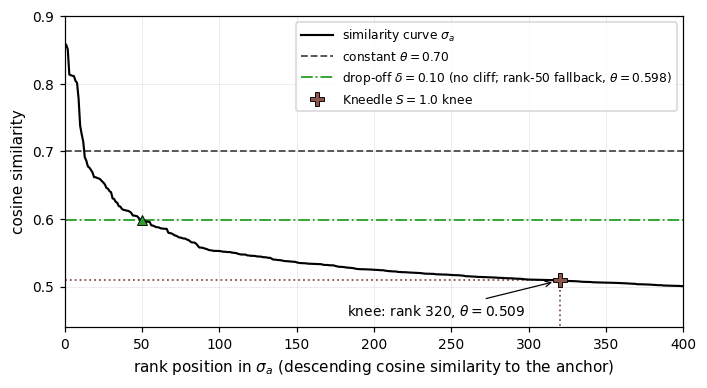

Saved: kneedle_curve.pdf + .png (200 dpi); x range 1..400

FIGURE data (anchor White Asparagus, product_id 5895)
  Kneedle S=1.0 knee : rank 320, theta 0.5092
  constant theta     : 0.70  (crosses the curve after rank 12)
  drop-off d=0.10    : fallback rank 50, theta 0.5979


In [6]:
X_MAX = 400
x = np.arange(1, X_MAX + 1)
y = ranked[:X_MAX]

# colours follow notebook 08's configuration palette; line style + marker carry the meaning too
COL_KNEE, COL_DROP, COL_CONST = "#8c564b", "#2ca02c", "0.30"

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.6))

ax.plot(x, y, color="black", ls="-", lw=1.4, label=r"similarity curve $\sigma_a$", zorder=3)

# constant baseline theta = 0.70
ax.axhline(CONSTANT_THETA, color=COL_CONST, ls="--", lw=1.2,
           label=rf"constant $\theta = {CONSTANT_THETA:.2f}$", zorder=2)

# drop-off delta = 0.10 (fallback: rank-50 similarity)
drop_label = (rf"drop-off $\delta = 0.10$ (no cliff; rank-{drop_rank} fallback, "
              rf"$\theta = {drop_theta:.3f}$)" if drop_fallback else
              rf"drop-off $\delta = 0.10$ (cliff at rank {drop_rank}, $\theta = {drop_theta:.3f}$)")
ax.axhline(drop_theta, color=COL_DROP, ls="-.", lw=1.2, label=drop_label, zorder=2)
ax.plot([drop_rank], [drop_theta], marker="^", ms=7, color=COL_DROP, mec="black", mew=0.6,
        ls="none", zorder=5)

# Kneedle knee (S = 1.0): guides to both axes + marker
ax.plot([knee_rank, knee_rank], [0, knee_theta], color=COL_KNEE, ls=":", lw=1.2, zorder=2)
ax.plot([0, knee_rank], [knee_theta, knee_theta], color=COL_KNEE, ls=":", lw=1.2, zorder=2)
ax.plot([knee_rank], [knee_theta], marker="P", ms=9, color=COL_KNEE, mec="black", mew=0.6,
        ls="none", zorder=6,
        label=r"Kneedle $S = 1.0$ knee")
ax.annotate(rf"knee: rank {knee_rank}, $\theta = {knee_theta:.3f}$",
            xy=(knee_rank, knee_theta), xytext=(knee_rank - 22, knee_theta - 0.045),
            ha="right", va="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="black", lw=0.8, shrinkA=2, shrinkB=5))

ax.set_xlim(0, X_MAX)
ax.set_ylim(0.44, 0.90)
ax.set_xlabel(r"rank position in $\sigma_a$ (descending cosine similarity to the anchor)")
ax.set_ylabel("cosine similarity")
ax.grid(alpha=0.3, linewidth=0.5)
ax.legend(loc="upper right", frameon=True, handlelength=2.6)
fig.tight_layout()

fig.savefig(FIG_DIR / "kneedle_curve.pdf")            # vector
fig.savefig(FIG_DIR / "kneedle_curve.png", dpi=200)   # raster preview
plt.show()
print("Saved:", (FIG_DIR / "kneedle_curve.pdf").name, "+ .png (200 dpi); x range 1..%d" % X_MAX)

print("\nFIGURE data (anchor %s, product_id %d)" % (anchor["name"], A_PID))
print(f"  Kneedle S=1.0 knee : rank {knee_rank}, theta {knee_theta:.4f}")
print(f"  constant theta     : {CONSTANT_THETA:.2f}  (crosses the curve after rank {const_kept})")
print(f"  drop-off d=0.10    : {'fallback ' if drop_fallback else ''}rank {drop_rank}, theta {drop_theta:.4f}")